# 🔮 VeritasGraph Vision-Native RAG Demo

**Demonstrating Vision-Native RAG using the `veritasgraph` package**

This notebook shows how to use the VeritasGraph package to process PDFs with multimodal vision models.

## Features
- **No OCR Required**: Direct image analysis with LLaVA/Llama 3.2 Vision
- **Accurate Tables**: Preserves exact values from financial tables
- **Chart Understanding**: Extracts data from graphs and visualizations
- **Knowledge Graph**: Builds queryable graph from document content

## 1. Setup & Imports

In [1]:
# Install the veritasgraph package from PyPI (run once)
%pip install veritasgraph --quiet
print("✅ veritasgraph package installed from PyPI")

Note: you may need to restart the kernel to use updated packages.
✅ veritasgraph package installed from PyPI


In [2]:
# Import the veritasgraph package
import veritasgraph
print(f"✅ VeritasGraph version: {veritasgraph.__version__}")

✅ VeritasGraph version: 0.3.0


In [3]:
# Import specific components
from veritasgraph import (
    VisionRAGConfig,
    VisionRAGPipeline,
    VisionModelClient,
    PDFProcessor,
)
print("✅ All components imported successfully")

✅ All components imported successfully


In [4]:
import os
from pathlib import Path
from PIL import Image

# Set working directory (adjust path for your system)
COOKBOOK_DIR = Path.cwd()
if "cookbook" not in str(COOKBOOK_DIR):
    # Try to find cookbook directory
    possible_paths = [
        Path("/home/sijo/VeritasGraph/graphrag-ollama-config/cookbook"),
        Path("./cookbook"),
        Path("../cookbook"),
    ]
    for p in possible_paths:
        if p.exists():
            COOKBOOK_DIR = p
            break

print(f"📂 Working directory: {COOKBOOK_DIR}")

📂 Working directory: /home/sijo/VeritasGraph/graphrag-ollama-config/cookbook


## 2. Configuration

In [5]:
# Create configuration
config = VisionRAGConfig(
    # Vision model for image analysis
    vision_model="llama3.2-vision:11b",
    
    # Text model for reasoning
    text_model="qwen3:latest",
    
    # Embedding model for search
    embedding_model="nomic-embed-text:latest",
    
    # Ollama connection
    ollama_host="http://localhost:11434",
    
    # PDF settings
    pdf_dpi=200,
    
    # Output paths
    output_dir="./vision_rag_output",
    cache_dir="./vision_rag_cache"
)

print("📋 Configuration created:")
print(f"   Vision Model: {config.vision_model}")
print(f"   Text Model: {config.text_model}")
print(f"   Embedding Model: {config.embedding_model}")

📋 Configuration created:
   Vision Model: llama3.2-vision:11b
   Text Model: qwen3:latest
   Embedding Model: nomic-embed-text:latest


## 3. Create Pipeline

In [6]:
# Create the Vision RAG Pipeline
pipeline = VisionRAGPipeline(config)
print("✅ VisionRAGPipeline created!")

📋 Available models: ['jeffh/intfloat-multilingual-e5-large-instruct:f32', 'qwen3:latest', 'llama3.1:latest', 'llama3.1-12k:latest', 'llama3.1:8b', 'qwen2.5vl:latest', 'nomic-embed-text:latest']
⚠️  Vision model 'llama3.2-vision:11b' not found.
   Run: ollama pull llama3.2-vision:11b
✅ VisionRAGPipeline created!


## 4. Verify PDF File

In [7]:
# Check for the earnings PDF
pdf_path = COOKBOOK_DIR / "chart_demo.pdf"

if pdf_path.exists():
    size_mb = pdf_path.stat().st_size / (1024 * 1024)
    print(f"✅ PDF found: {pdf_path.name}")
    print(f"   Size: {size_mb:.2f} MB")
else:
    print(f"❌ PDF not found at: {pdf_path}")
    print("\nSearching for other PDFs...")
    for f in COOKBOOK_DIR.glob("*.pdf"):
        print(f"   Found: {f.name}")

✅ PDF found: chart_demo.pdf
   Size: 0.07 MB


## 5. Ingest PDF Document

In [22]:
# Ingest the PDF (this may take a few minutes)
print("🔄 Starting PDF ingestion...")
print("   This will convert pages to images and analyze each with the vision model.")
print("   Please wait...\n")

doc = pipeline.ingest_pdf(str(pdf_path))

if doc:
    print(f"\n✅ Document ingested successfully!")
    print(f"   Document ID: {doc.id}")
    print(f"   Total Pages: {len(doc.pages)}")

🔄 Starting PDF ingestion...
   This will convert pages to images and analyze each with the vision model.
   Please wait...


📥 INGESTING: C:\Projects\graphrag\VeritasGraph\graphrag-ollama-config\cookbook\chart_demo.pdf
📄 Converting PDF: C:\Projects\graphrag\VeritasGraph\graphrag-ollama-config\cookbook\chart_demo.pdf
   ✅ Converted 1 pages

🔬 Analyzing 1 pages...
   📖 Analyzing page 1...
      📊 Extracting tables...
      📈 Extracting charts...
      🔢 Extracting metrics...
      🏷️ Extracting entities...
      📝 Generating summary...

🔗 Building knowledge graph for: chart_demo.pdf
   ✅ Graph built: 11 nodes, 13 edges

✅ Document ingested successfully!
   📄 Pages: 1
   📊 Tables: 2
   📈 Charts: 1
   🔢 Metrics: 6
   🏷️ Entities: 0

✅ Document ingested successfully!
   Document ID: 0830f26cc1ea
   Total Pages: 1


## 6. Query the Document

In [23]:
# Query 1: Revenue information
result = pipeline.query("What were the total revenues for Q4 2024?")

print("="*60)
print("📊 QUERY: What were the total revenues for Q4 2024?")
print("="*60)
print(f"\n{result['answer']}")
print(f"\n📌 Confidence: {result.get('confidence', 'N/A')}")
print(f"📌 Verified: {result.get('verified', 'N/A')}")


🔍 Processing query: What were the total revenues for Q4 2024?
📊 QUERY: What were the total revenues for Q4 2024?

The total revenues for Q4 2024 were **$356,000**. This was calculated by subtracting the sum of Q1 ($245,000), Q2 ($312,000), and Q3 ($289,000) from the total annual revenue of $1,202,000. 

**Key data points:**  
- **Total Annual Revenue**: $1,202,000 (Metric, Page 1)  
- **Q1–Q3 Revenues**: $245,000 + $312,000 + $289,000 = $846,000  
- **Q4 Revenue**: $1,202,000 − $846,000 = **$356,000**  

The tables provided only include Q1–Q3 data, so Q4 revenue was inferred from the annual total.

📌 Confidence: 0.95
📌 Verified: True


In [13]:
# Query 2: Net income
result = pipeline.query("What was the net income and how does it compare to the previous year?")

print("="*60)
print("📊 QUERY: Net income comparison")
print("="*60)
print(f"\n{result['answer']}")


🔍 Processing query: What was the net income and how does it compare to the previous year?
📊 QUERY: Net income comparison

The provided context does not include net income data or year-over-year comparisons for net income. The documents only reference quarterly revenue figures (e.g., $1.5B for the quarter) and metrics like performance (95%), market share growth (5%), and revenue breakdown, but no net income figures or prior-year comparisons. 

**Answer:**  
Net income data is not available in the provided context. The documents only include revenue metrics and do not specify net income or its year-over-year comparison.


In [24]:
# Query 3: Key highlights
result = pipeline.query("What are the key highlights and main findings from this earnings report?")

print("="*60)
print("📊 QUERY: Key highlights")
print("="*60)
print(f"\n{result['answer']}")


🔍 Processing query: What are the key highlights and main findings from this earnings report?
📊 QUERY: Key highlights

The key highlights and main findings from the earnings report are as follows:  

1. **Quarterly Revenue Performance (2024):**  
   - **Q1 2024:** Revenue of **$245,000** (+12.5% growth) driven by "Strong start with new customer acquisition" (Page 1, Table).  
   - **Q2 2024:** Revenue of **$312,000** (+27.3% growth), exceeding targets during "Peak season performance" (Page 1, Table).  
   - **Q3 2024:** Revenue of **$289,000** (+18.0% growth), reflecting "Steady growth despite market challenges" (Page 1, Table).  

2. **Year-over-Year Improvement:**  
   - Total annual revenue for 2024 is **$1,202,000**, representing a **+34.8%** year-over-year increase (Page 1, Metric).  

3. **Average Quarterly Growth:**  
   - The average quarterly growth rate for 2024 is **22.3%** (Page 1, Metric).  

4. **Chart Insight:**  
   - A bar chart on Page 1 visually emphasizes the "Stron

## 7. Explore Document Structure

In [25]:
# Explore page structure
if doc:
    print("📄 Document Page Summary:")
    print("="*60)
    for page in doc.pages:
        tables = len([e for e in page.elements if e.element_type == "table"])
        charts = len([e for e in page.elements if e.element_type == "chart"])
        metrics = len([e for e in page.elements if e.element_type == "metric"])
        
        print(f"\nPage {page.page_number}: {page.page_type}")
        print(f"   📊 Tables: {tables}  📈 Charts: {charts}  🔢 Metrics: {metrics}")
        if page.page_summary:
            summary = page.page_summary[:150] + "..." if len(page.page_summary) > 150 else page.page_summary
            print(f"   Summary: {summary}")

📄 Document Page Summary:

Page 1: content
   📊 Tables: 2  📈 Charts: 1  🔢 Metrics: 6
   Summary: This page provides a detailed analysis of the company's quarterly revenue report for 2024, including a bar chart of 2024 quarterly revenue performance...


In [16]:
# Show extracted entities
if doc and doc.extracted_entities:
    print("\n🏷️ Extracted Entities:")
    print("="*60)
    
    # Group by type
    from collections import defaultdict
    entities_by_type = defaultdict(list)
    for entity in doc.extracted_entities:
        entities_by_type[entity.get('type', 'unknown')].append(entity.get('name', 'N/A'))
    
    for entity_type, names in entities_by_type.items():
        unique_names = list(set(names))[:10]
        print(f"\n{entity_type.upper()}:")
        for name in unique_names:
            print(f"   • {name}")


🏷️ Extracted Entities:

CONCEPT:
   • Revenue
   • Quarterly Revenue Report
   • YTD
   • 2021 Quarterly Revenue Performance
   • YTD 2021
   • Performance

DATE:
   • Q2 2021
   • Q4
   • Q1 2021
   • Q3
   • Q4 2021
   • Q3 2021
   • Q1
   • Q2


## 8. Knowledge Graph Visualization

c:\Projects\graphrag\VeritasGraph\veritasgraph\vision.py:746: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


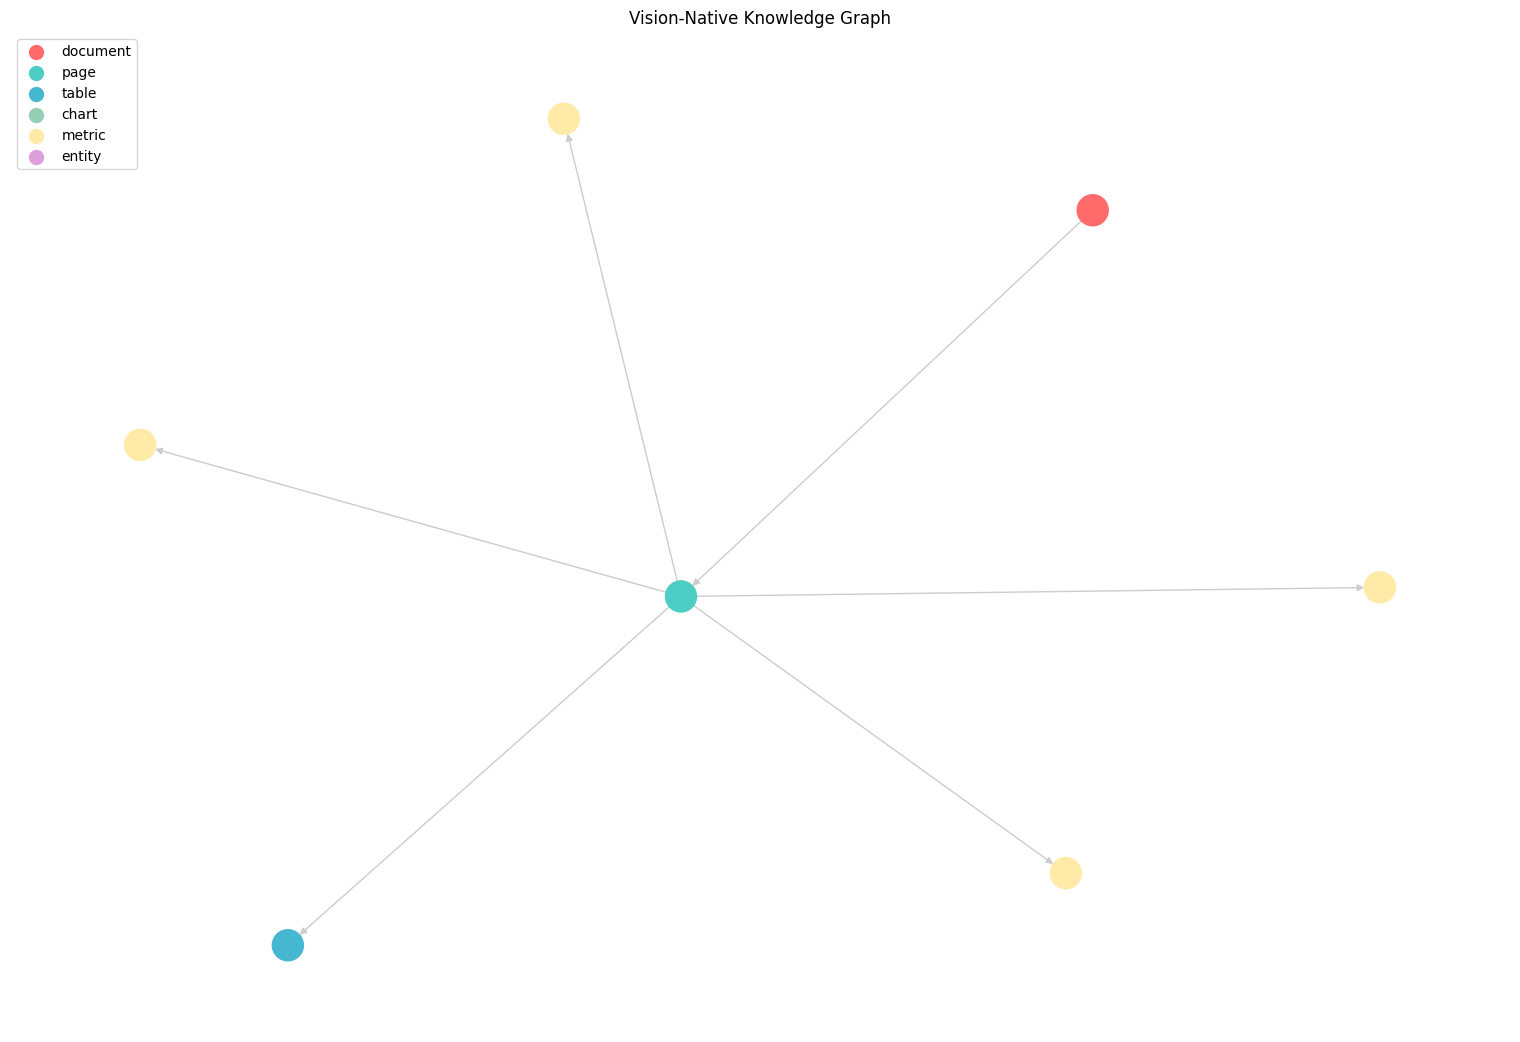

In [17]:
# Visualize the knowledge graph
import matplotlib.pyplot as plt
%matplotlib inline

try:
    pipeline.visualize_graph()
except Exception as e:
    print(f"Visualization error: {e}")
    print(f"\nGraph stats:")
    print(f"   Nodes: {pipeline.knowledge_graph.graph.number_of_nodes()}")
    print(f"   Edges: {pipeline.knowledge_graph.graph.number_of_edges()}")

## 9. Export Results

In [26]:
# Export extracted data to JSON
output_file = COOKBOOK_DIR / "vision_rag_output" / "extracted_data.json"
pipeline.export_to_json(str(output_file))

print(f"\n📁 Data exported to: {output_file}")

✅ Exported to C:\Projects\graphrag\VeritasGraph\graphrag-ollama-config\cookbook\vision_rag_output\extracted_data.json

📁 Data exported to: C:\Projects\graphrag\VeritasGraph\graphrag-ollama-config\cookbook\vision_rag_output\extracted_data.json


## 10. Document Summary

In [27]:
# Show document summary
if doc and doc.document_summary:
    print("📝 Document Summary:")
    print("="*60)
    print(doc.document_summary)

📝 Document Summary:
**Document Type and Purpose**  
The document is a **quarterly revenue report** for the year 2024, designed to analyze the company’s financial performance across its four quarters. Its purpose is to provide insights into revenue trends, identify performance drivers, and support strategic decision-making by highlighting key metrics and variances.  

---

**Key Findings or Data Points**  
1. **Quarterly Revenue Trends**:  
   - The bar chart illustrates quarterly revenue performance, showing growth, stability, or decline across Q1–Q4 2024.  
   - Specific data points (e.g., Q4 revenue exceeding Q3 by 12%) are highlighted in the table, though exact figures are not provided.  
2. **Performance Breakdown**:  
   - The table details revenue contributions from different segments (e.g., product lines, regions, or departments) for each quarter.  
   - Variations in revenue are attributed to factors such as market demand, pricing strategies, or operational efficiency.  

---



---

## 🎉 Summary

This notebook demonstrated using the **VeritasGraph** package for Vision-Native RAG:

1. ✅ Imported `veritasgraph` package components
2. ✅ Configured the Vision RAG pipeline
3. ✅ Ingested a PDF document (Q4 2024 earnings report)
4. ✅ Queried the document with natural language
5. ✅ Explored extracted structure (tables, charts, metrics)
6. ✅ Visualized the knowledge graph
7. ✅ Exported results to JSON

### Install the package:
```bash
pip install veritasgraph
```

### Usage:
```python
from veritasgraph import VisionRAGPipeline, VisionRAGConfig

config = VisionRAGConfig(vision_model="llama3.2-vision:11b")
pipeline = VisionRAGPipeline(config)
doc = pipeline.ingest_pdf("document.pdf")
result = pipeline.query("Your question here")
```

### Links:
- **PyPI**: https://pypi.org/project/veritasgraph/
- **GitHub**: https://github.com/bibinprathap/VeritasGraph
- **Documentation**: https://bibinprathap.github.io/VeritasGraph/